# ***Fitting Binarized Neural Networks project***

---



---



## CODE NOTEBOOK PREMISE ⚛

This notebook contains all the code I produced for the development of the **Knowledge Representation and Learning project** - *University of Padua (A.Y. 2023-2024)*.

### IMPORT PACKAGES & USEFUL ISTALLATION

In [77]:
# common pakages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from random import randrange
from itertools import permutations
from sklearn.metrics import accuracy_score, balanced_accuracy_score # accuracy for imbalanced dataset - recall avg obtained on each class -
                                                                    # (y_true, y_pred)

In [78]:
!pip install python-sat[pblib,aiger]

In [79]:
# pakages specific for pySAT
from pysat.formula import CNF
from pysat.formula import WCNF
from pysat.examples.rc2 import RC2

### SOME UTILITY FUNCTIONS

In [80]:
def fun(res):
    if res > 0:
        return 1
    return -1

In [81]:
def pred(weights, X): # fuction to do the prediction
  return fun(np.dot(weights, X))

In [82]:
def perc_elem_SAT_UNSAT(weights, m, n): # % of SAT and UNSAT element for the weights configuration

  SAT = 0; UNSAT = 0;

  if n == 1:
    for i in weights:
      if i == 1: # sat element
        SAT +=1
      else: # unsat element
        UNSAT +=1

    print(f"% of SAT elements of the weights configuration: {SAT / m * 100:05.2f} %")
    print(f"% of UNSAT elements of the weights configuration: {UNSAT / m * 100:05.2f} %")

  elif n == 3:
    for i in range (0, n): # [0 to 2]
        for j in range (0, m): #[0 to 4]
          if weights[i][j] == 1: # sat element
           SAT +=1
          else: # unsat element
            UNSAT +=1

    print(f"% of SAT elements of the weights configuration: {SAT / (m*n) * 100:05.2f} %")
    print(f"% of UNSAT elements of the weights configuration: {UNSAT / (m*n) * 100:05.2f} %")


  else: # n == 5
    for i in range (0, n): # [0 to 4]
      for j in range (0, n):
        if weights[i][j] == 1: # sat element
          SAT +=1
        else: # unsat element
          UNSAT +=1

    print(f"% of SAT elements of the weights configuration: {SAT / (m*m) * 100:05.2f} %")
    print(f"% of UNSAT elements of the weights configuration: {UNSAT / (m*m) * 100:05.2f} %")

## LOGIC OPERATORS for the IMPLEMENTATION of the *BNNs* ⚛

#### **NO HIDDEN LAYERS VERSION**
* Only *input* and *output* layers;
* *Single perceptron inspiration*;
* *Boolean operators:* **OR, AND, NOT**.
   

In [83]:
# boolean operator for single perceptron

def OR(x): # binary function
  for i in x:
    if i == 1:
      return 1
  return -1

def AND(x): # binary function
  for i in x:
    if i == -1:
      return -1
  return 1

def NOT(x): # unary function
  if x == [1]:
    return -1
  return 1

#### **HIDDEN LAYERS VERSION**
* *At least one hidden layer*;
* *Multilayer perceptron inspiration*;
* *Boolean operators:* **XOR, XNOR, NOR, NAND**.

In [84]:
# boolean operator for multilayer perceptron

def XOR(x): # exclusive OR [-1,-1] - [1,1] = false
  for p in range(0, len(x)-1):
    if x[p] == x[p+1]:
       return -1
  return 1

def XNOR(x): # NOT(XOR): [-1,-1] - [1,1] = true
  return NOT([XOR(x)])

def NOR(x): # NOT(OR)
  return NOT([OR(x)])

def NAND(x): # NOT(AND)
  return NOT([AND(x)])

## NETWORK ARCHITECTURES & DATASETS ⚛

In this section I present all the *BNNs architectures* and related *datasets*, that I decided to develop for the puposes of this project.

In particular, I decide to implement different net configurations based on:

* number of **input neurons** (m);
* number of **output neurons** (n);
* number and type of **binary functions** implemented.

Moreover, it is important to specify that: each input neuron of the net encodes a single *prepositional variable* (with value 1 or -1). In contrast, each output neuron, represents one single *formula* (with value 1 or -1).


##### **m** preposition variables as inputs, 1 binary function and **n=1** as output (one single formula obtained) - *SINGLE PERCEPTRON INSPIRATION*.

In [85]:
# GLOBAL VARIABLES

# MY MODEL 1
examples = 200;
m = 2; # INPUT NEURONS: number of prepositional variables for each row => with the application of the binary function I obtain a formula (base on the binary function used)
n = 1; # OUTPUT NEURONS: in this case I used only one binary function => I obtain only one formula as output

# MY MODEL 2
# examples = 10000;
# m = 3; # INPUT NEURONS: number of prepositional variables for each row => with the application of the binary function I obtain a formula (base on the binary function used)
# n = 1; # OUTPUT NEURONS: in this case I used only one binary function => I obtain only one formula as output

X = []; # pairs [(x1, ... ,xm); y]

for i in range(examples): # generation of some integers (1 or -1)
  row = [];
  for _ in range(0, m):
    row.append(randrange(-1, 2, 2)) # start, stop, step

  # different y_target based on the logic operation used
  # SINGLE PERCEPTRON

  # MY MODEL 1
  y_target = AND(row)

  # MY MODEL 2
  # y_target = OR(row)

  #######################
  # binary/unary functions
  #y_target = OR(row)
  #y_target = AND(row)
  #y_target = NOT(row)
  ########################

  X.append(tuple([row, y_target]))

print ("PARAMETERS OF MY NET :-)")
print ("+----------------------------+")
print ("DIM input:", m)
print ("DIM output:", n)
print("DIM vector weights:", len(X[0][0]), "*", n, "\n")
print("Binary function implemented: AND")
print ("+----------------------------+")
print("OKAY, DATASET realized :-) <<")

PARAMETERS OF MY NET :-)
+----------------------------+
DIM input: 2
DIM output: 1
DIM vector weights: 2 * 1 

Binary function implemented: AND
+----------------------------+
OKAY, DATASET realized :-) <<


In [86]:
print("MY DATASET ([data, label]) =====>")
print(X)
print ("+----------------------------+")
print("Total number of examples in MY DATASET: ", len(X))
print("Number of prepositional variables for every row of MY DATASET: ", m)
print("Number of leables for every row of MY DATASET: ", n)

MY DATASET ([data, label]) =====>
[([-1, 1], -1), ([-1, -1], -1), ([-1, 1], -1), ([-1, 1], -1), ([-1, -1], -1), ([-1, 1], -1), ([-1, 1], -1), ([1, 1], 1), ([1, -1], -1), ([-1, -1], -1), ([-1, 1], -1), ([1, 1], 1), ([1, 1], 1), ([-1, -1], -1), ([-1, -1], -1), ([1, -1], -1), ([1, -1], -1), ([-1, -1], -1), ([1, 1], 1), ([1, -1], -1), ([1, -1], -1), ([-1, 1], -1), ([-1, -1], -1), ([1, -1], -1), ([-1, 1], -1), ([1, 1], 1), ([1, -1], -1), ([1, -1], -1), ([1, 1], 1), ([-1, -1], -1), ([1, -1], -1), ([-1, -1], -1), ([1, 1], 1), ([1, -1], -1), ([-1, 1], -1), ([1, 1], 1), ([1, 1], 1), ([-1, 1], -1), ([-1, 1], -1), ([-1, 1], -1), ([-1, -1], -1), ([1, 1], 1), ([-1, 1], -1), ([-1, 1], -1), ([-1, 1], -1), ([1, 1], 1), ([-1, 1], -1), ([1, -1], -1), ([-1, -1], -1), ([-1, 1], -1), ([-1, -1], -1), ([1, 1], 1), ([-1, 1], -1), ([-1, 1], -1), ([1, -1], -1), ([-1, 1], -1), ([-1, 1], -1), ([1, -1], -1), ([1, -1], -1), ([-1, -1], -1), ([1, -1], -1), ([-1, 1], -1), ([-1, 1], -1), ([-1, 1], -1), ([-1, -1], -1), 

#####**m** preposition variables as inputs, 1 binary function and **n=1** as output (one single formula obtained) - *MULTILAYER PERCEPTRON INSPIRATION*.

In [87]:
# GLOBAL VARIABLES

# MY MODEL 1, 2, 3, 4
examples = 200;
m = 2; # INPUT NEURONS: number of prepositional variables for each row => with the application of the binary function I obtain a formula (base on the binary function used)
n = 1; # OUTPUT NEURONS: in this case I used only one binary function => I obtain only one formula as output

X = []; # pairs [(x1, ... ,xm); y]

for i in range(examples): # generation of some integers (1 or -1)
  row = [];
  for _ in range(0, m):
    row.append(randrange(-1, 2, 2)) # start, stop, step

  # MULTILAYER PERCEPTRON

  # MY MODEL 1
  # y_target = NAND(row)

  # MY MODEL 2
  y_target = NOR(row)

  # MY MODEL 3
  # y_target = XOR(row)

  # MY MODEL 4
  # y_target = XNOR(row)

  #######################
  # binary functions
  #y_target = XOR(row)
  #y_target = XNOR(row)
  #y_target = NOR(row)
  #y_target = NAND(row)
  #######################

  X.append(tuple([row, y_target]))

print ("PARAMETERS OF MY NET :-)")
print ("+----------------------------+")
print ("DIM input:", m)
print ("DIM output:", n)
print("DIM vector weights:", len(X[0][0]), "*", n, "\n")
print("Binary function implemented: NOR")
print ("+----------------------------+")
print("OKAY, DATASET realized :-) <<")

PARAMETERS OF MY NET :-)
+----------------------------+
DIM input: 2
DIM output: 1
DIM vector weights: 2 * 1 

Binary function implemented: NOR
+----------------------------+
OKAY, DATASET realized :-) <<


In [88]:
print("MY DATASET ([data, label]) =====>")
print(X)
print ("+----------------------------+")
print("Total number of examples in MY DATASET: ", len(X))
print("Number of prepositional variables for every row of MY DATASET: ", m)
print("Number of leables for every row of MY DATASET: ", n)

MY DATASET ([data, label]) =====>
[([-1, -1], 1), ([1, 1], -1), ([-1, -1], 1), ([1, -1], -1), ([1, 1], -1), ([1, 1], -1), ([1, 1], -1), ([1, 1], -1), ([-1, 1], -1), ([-1, -1], 1), ([1, 1], -1), ([1, 1], -1), ([-1, -1], 1), ([1, -1], -1), ([1, -1], -1), ([1, 1], -1), ([1, 1], -1), ([-1, 1], -1), ([1, -1], -1), ([1, -1], -1), ([-1, -1], 1), ([1, -1], -1), ([-1, -1], 1), ([-1, 1], -1), ([1, -1], -1), ([1, 1], -1), ([1, 1], -1), ([1, -1], -1), ([-1, 1], -1), ([1, -1], -1), ([1, 1], -1), ([1, 1], -1), ([1, 1], -1), ([-1, -1], 1), ([-1, 1], -1), ([-1, -1], 1), ([-1, 1], -1), ([1, -1], -1), ([-1, 1], -1), ([1, 1], -1), ([-1, 1], -1), ([-1, 1], -1), ([-1, -1], 1), ([1, 1], -1), ([1, -1], -1), ([1, 1], -1), ([1, 1], -1), ([-1, -1], 1), ([-1, 1], -1), ([-1, 1], -1), ([1, 1], -1), ([-1, 1], -1), ([-1, -1], 1), ([-1, -1], 1), ([1, -1], -1), ([1, -1], -1), ([1, -1], -1), ([-1, -1], 1), ([-1, -1], 1), ([1, -1], -1), ([1, -1], -1), ([1, -1], -1), ([-1, 1], -1), ([-1, 1], -1), ([-1, 1], -1), ([1, 1], 

#####**m** preposition variables as inputs, **3 binary functions** and **n=3** as outputs (3 formulas obtainded) - *SINGLE PERCEPTRON INSPIRATION*.

In [89]:
# GLOBAL VARIABLES

# MY MODEL 1
examples = 200;
m = 3; # INPUT NEURONS: number of prepositional variables for each row => with the application of the binary function I obtain a formula (base on the binary function used)
n = 3; # OUTPUT NEURONS: in this case since I use 3 binary functions => I obtain 3 formulas as output

X = []; # pair [(x1, ... ,xm); y]

for i in range(examples): # generation of some integers (1 or -1)
  row = [];
  for _ in range(0, m):
    row.append(randrange(-1, 2, 2)) # start, stop, step

  # different y_target based on the logic operation used
  # SINGLE PERCEPTRON

  # MY MODEL 1
  y_target1 = OR(row)
  y_target2 = OR(row)
  y_target3 = OR(row)

  #######################
  # binary functions
  #y_target = OR(row)
  #y_target = AND(row)
  #y_target = NOT(row)
  #######################

  X.append(tuple([row, y_target1, y_target2, y_target3]))

print ("PARAMETERS OF MY NET :-)")
print ("+----------------------------+")
print ("DIM input:", m)
print ("DIM output:", n)
print("DIM vector weights:", len(X[0][0]), "*", n, "\n")
print("Binary functions implemented: OR")
print ("+----------------------------+")
print("OKAY, DATASET realized :-) <<")

#print(X)
#print(X[0][1]) # 1 ex lable 1
#print(X[0][2]) # 1 ex lable 2
#print(X[0][3]) # 1 ex lable 3

PARAMETERS OF MY NET :-)
+----------------------------+
DIM input: 3
DIM output: 3
DIM vector weights: 3 * 3 

Binary functions implemented: OR
+----------------------------+
OKAY, DATASET realized :-) <<


In [90]:
print("MY DATASET ([data, label]) =====>")
print(X)
print ("+----------------------------+")
print("Total number of examples in MY DATASET: ", len(X))
print("Number of prepositional variables for every row of MY DATASET: ", m)
print("Number of leables for every row of MY DATASET: ", n)

MY DATASET ([data, label]) =====>
[([1, -1, 1], 1, 1, 1), ([1, -1, 1], 1, 1, 1), ([1, -1, 1], 1, 1, 1), ([1, -1, -1], 1, 1, 1), ([1, 1, 1], 1, 1, 1), ([-1, -1, 1], 1, 1, 1), ([1, -1, 1], 1, 1, 1), ([1, -1, 1], 1, 1, 1), ([-1, 1, 1], 1, 1, 1), ([-1, 1, 1], 1, 1, 1), ([-1, -1, 1], 1, 1, 1), ([-1, 1, -1], 1, 1, 1), ([1, 1, -1], 1, 1, 1), ([1, 1, -1], 1, 1, 1), ([1, -1, 1], 1, 1, 1), ([1, 1, -1], 1, 1, 1), ([1, -1, 1], 1, 1, 1), ([1, 1, -1], 1, 1, 1), ([1, 1, -1], 1, 1, 1), ([1, 1, -1], 1, 1, 1), ([-1, 1, -1], 1, 1, 1), ([1, -1, 1], 1, 1, 1), ([-1, -1, -1], -1, -1, -1), ([1, 1, 1], 1, 1, 1), ([-1, -1, 1], 1, 1, 1), ([-1, -1, 1], 1, 1, 1), ([1, 1, 1], 1, 1, 1), ([1, -1, -1], 1, 1, 1), ([-1, -1, 1], 1, 1, 1), ([1, 1, 1], 1, 1, 1), ([-1, -1, 1], 1, 1, 1), ([1, -1, 1], 1, 1, 1), ([-1, 1, -1], 1, 1, 1), ([1, -1, 1], 1, 1, 1), ([-1, -1, 1], 1, 1, 1), ([-1, -1, 1], 1, 1, 1), ([1, 1, -1], 1, 1, 1), ([1, 1, -1], 1, 1, 1), ([-1, 1, 1], 1, 1, 1), ([1, -1, -1], 1, 1, 1), ([1, 1, -1], 1, 1, 1), ([1, -1

#####**m** preposition variables as inputs, **3 binary functions** and **n=3** as outputs (3 formulas obtainded) - *MULTILAYER PERCEPTRON INSPIRATION*.

In [91]:
# GLOBAL VARIABLES

# MY MODEL 1, 2
examples = 200;
m = 3; # INPUT NEURONS: number of prepositional variables for each row => with the application of the binary function I obtain a formula (base on the binary function used)
n = 3; # OUTPUT NEURONS: in this case since I use 3 binary functions => I obtain 3 formulas as output

# MY MODEL 3
# examples = 5000;
# m = 5; # INPUT NEURONS: number of prepositional variables for each row => with the application of the binary function I obtain a formula (base on the binary function used)
# n = 3; # OUTPUT NEURONS: in this case since I use 3 binary functions => I obtain 3 formulas as output

# MY MODEL 4
# examples = 100;
# m = 3; # INPUT NEURONS: number of prepositional variables for each row => with the application of the binary function I obtain a formula (base on the binary function used)
# n = 3; # OUTPUT NEURONS: in this case since I use 3 binary functions => I obtain 3 formulas as output

X = []; # pair [(x1, ... ,xm); y]

for i in range(examples): # generation of some integers (1 or -1)
  row = [];
  for _ in range(0, m):
    row.append(randrange(-1, 2, 2)) # start, stop, step

  # different y_target based on the logic operation used
  # MULTILAYER PERCEPTRON

  # MY MODEL 1
  y_target1 = XNOR(row)
  y_target2 = NOR(row)
  y_target3 = XNOR(row)

  # MY MODEL 2, 4
  # y_target1 = NAND(row)
  # y_target2 = XNOR(row)
  # y_target3 = NOR(row)

  #MY MODEL 3
  # y_target1 = NAND(row)
  # y_target2 = NAND(row)
  # y_target3 = NAND(row)

  #########################
  # binary functions
  #y_target = XOR(row)
  #y_target = XNOR(row)
  #y_target = NOR(row)
  #y_target = NAND(row)
  #########################

  X.append(tuple([row, y_target1, y_target2, y_target3]))

print ("PARAMETERS OF MY NET :-)")
print ("+----------------------------+")
print ("DIM input:", m)
print ("DIM output:", n)
print("DIM vector weights:", len(X[0][0]), "*", n, "\n")
print("Binary functions implemented: XNOR, NOR")
print ("+----------------------------+")
print("OKAY, DATASET realized :-) <<")

PARAMETERS OF MY NET :-)
+----------------------------+
DIM input: 3
DIM output: 3
DIM vector weights: 3 * 3 

Binary functions implemented: XNOR, NOR
+----------------------------+
OKAY, DATASET realized :-) <<


In [92]:
print("MY DATASET ([data, label]) =====>")
print(X)
print ("+----------------------------+")
print("Total number of examples in MY DATASET: ", len(X))
print("Number of prepositional variables for every row of MY DATASET: ", m)
print("Number of leables for every row of MY DATASET: ", n)

MY DATASET ([data, label]) =====>
[([1, -1, -1], 1, -1, 1), ([1, 1, 1], 1, -1, 1), ([1, -1, 1], -1, -1, -1), ([1, 1, 1], 1, -1, 1), ([-1, 1, -1], -1, -1, -1), ([-1, -1, 1], 1, -1, 1), ([1, 1, 1], 1, -1, 1), ([1, 1, 1], 1, -1, 1), ([-1, -1, -1], 1, 1, 1), ([-1, 1, -1], -1, -1, -1), ([1, -1, 1], -1, -1, -1), ([-1, -1, 1], 1, -1, 1), ([-1, 1, -1], -1, -1, -1), ([-1, 1, 1], 1, -1, 1), ([-1, -1, -1], 1, 1, 1), ([-1, -1, -1], 1, 1, 1), ([-1, 1, -1], -1, -1, -1), ([1, -1, 1], -1, -1, -1), ([1, -1, -1], 1, -1, 1), ([1, 1, -1], 1, -1, 1), ([-1, -1, -1], 1, 1, 1), ([-1, 1, -1], -1, -1, -1), ([-1, 1, -1], -1, -1, -1), ([1, -1, -1], 1, -1, 1), ([-1, 1, 1], 1, -1, 1), ([1, 1, -1], 1, -1, 1), ([-1, 1, 1], 1, -1, 1), ([1, 1, -1], 1, -1, 1), ([1, 1, -1], 1, -1, 1), ([-1, -1, 1], 1, -1, 1), ([-1, -1, 1], 1, -1, 1), ([-1, -1, 1], 1, -1, 1), ([-1, 1, 1], 1, -1, 1), ([1, 1, 1], 1, -1, 1), ([1, -1, 1], -1, -1, -1), ([1, -1, 1], -1, -1, -1), ([1, -1, 1], -1, -1, -1), ([1, 1, -1], 1, -1, 1), ([-1, 1, -1], -1

#####**m** preposition variables as inputs, **5 binary functions** and **n=5** as outputs (5 formulas obtainded) - *SINGLE PERCEPTRON INSPIRATION*.

In [93]:
# GLOBAL VARIABLES

# MY MODEL 1
examples = 200;
m = 5; # INPUT NEURONS: number of prepositional variables for each row => with the application of the binary function I obtain a formula (base on the binary function used)
n = 5; # OUTPUT NEURONS: in this case since I use 3 binary functions => I obtain 3 formulas as output

X = []; # pair [(x1, ... ,xm); y]

for i in range(examples): # generation of some integers (1 or -1)
  row = [];
  for _ in range(0, m):
    row.append(randrange(-1, 2, 2)) # start, stop, step

  # different y_target based on the logic operation used
  # SINGLE PERCEPTRON

  # MY MODEL 1
  y_target1 = OR(row)
  y_target2 = OR(row)
  y_target3 = OR(row)
  y_target4 = OR(row)
  y_target5 = OR(row)

  #######################
  # binary functions
  #y_target = OR(row)
  #y_target = AND(row)
  #y_target = NOT(row)
  #######################

  X.append(tuple([row, y_target1, y_target2, y_target3, y_target4, y_target5]))

print ("PARAMETERS OF MY NET :-)")
print ("+----------------------------+")
print ("DIM input:", m)
print ("DIM output:", n)
print("DIM vector weights:", len(X[0][0]), "*", n, "\n")
print("Binary functions implemented: OR")
print ("+----------------------------+")
print("OKAY, DATASET realized :-) <<")

PARAMETERS OF MY NET :-)
+----------------------------+
DIM input: 5
DIM output: 5
DIM vector weights: 5 * 5 

Binary functions implemented: OR
+----------------------------+
OKAY, DATASET realized :-) <<


In [94]:
print("MY DATASET ([data, label]) =====>")
print(X)
print ("+----------------------------+")
print("Total number of examples in MY DATASET: ", len(X))
print("Number of prepositional variables for every row of MY DATASET: ", m)
print("Number of leables for every row of MY DATASET: ", n)

MY DATASET ([data, label]) =====>
[([1, 1, -1, -1, 1], 1, 1, 1, 1, 1), ([1, 1, -1, 1, 1], 1, 1, 1, 1, 1), ([-1, 1, -1, -1, -1], 1, 1, 1, 1, 1), ([1, -1, -1, -1, 1], 1, 1, 1, 1, 1), ([1, -1, -1, 1, -1], 1, 1, 1, 1, 1), ([1, 1, -1, -1, 1], 1, 1, 1, 1, 1), ([1, -1, 1, -1, 1], 1, 1, 1, 1, 1), ([1, -1, -1, 1, -1], 1, 1, 1, 1, 1), ([1, 1, 1, -1, 1], 1, 1, 1, 1, 1), ([-1, -1, 1, -1, 1], 1, 1, 1, 1, 1), ([-1, -1, 1, -1, 1], 1, 1, 1, 1, 1), ([1, 1, 1, -1, 1], 1, 1, 1, 1, 1), ([1, -1, -1, 1, -1], 1, 1, 1, 1, 1), ([1, -1, -1, -1, 1], 1, 1, 1, 1, 1), ([-1, 1, 1, 1, 1], 1, 1, 1, 1, 1), ([1, 1, 1, 1, -1], 1, 1, 1, 1, 1), ([1, 1, -1, -1, -1], 1, 1, 1, 1, 1), ([-1, -1, -1, -1, 1], 1, 1, 1, 1, 1), ([1, -1, -1, 1, -1], 1, 1, 1, 1, 1), ([-1, 1, -1, -1, 1], 1, 1, 1, 1, 1), ([-1, -1, 1, 1, -1], 1, 1, 1, 1, 1), ([1, -1, 1, 1, -1], 1, 1, 1, 1, 1), ([-1, 1, -1, -1, -1], 1, 1, 1, 1, 1), ([-1, 1, -1, -1, 1], 1, 1, 1, 1, 1), ([-1, 1, -1, 1, -1], 1, 1, 1, 1, 1), ([-1, 1, -1, 1, 1], 1, 1, 1, 1, 1), ([-1, -1, 1, 1,

##### **m** preposition variables as inputs, **5 binary functions** and **n=5** as outputs (5 formulas obtainded) - *MULTILAYER PERCEPTRON INSPIRATION*.

In [95]:
# GLOBAL VARIABLES

# MY MODEL 1
examples = 100;
m = 5; # INPUT NEURONS: number of prepositional variables for each row => with the application of the binary function I obtain a formula (base on the binary function used)
n = 5; # OUTPUT NEURONS: in this case since I use 5 binary functions => I obtain 5 formulas as output

# MY MODEL 2, 3
#examples = 1000;
#m = 5; # INPUT NEURONS: number of prepositional variables for each row => with the application of the binary function I obtain a formula (base on the binary function used)
#n = 5; # OUTPUT NEURONS: in this case since I use 5 binary functions => I obtain 5 formulas as output

X = []; # pair [(x1, ... ,xm); y]

for i in range(examples): # generation of some integers (1 or -1)
  row = [];
  for _ in range(0, m):
    row.append(randrange(-1, 2, 2)) # start, stop, step

  # different y_target based on the logic operation used
  # MULTILAYER PERCEPTRON

  # MY MODEL 1
  y_target1 = XNOR(row)
  y_target2 = NOR(row)
  y_target3 = XNOR(row)
  y_target4 = NOR(row)
  y_target5 = XNOR(row)

  # MY MODEL 2
  #y_target1 = NAND(row)
  #y_target2 = NOR(row)
  #y_target3 = NAND(row)
  #y_target4 = NOR(row)
  #y_target5 = NAND(row)

  # MY MODEL 3
  #y_target1 = NAND(row)
  #y_target2 = NAND(row)
  #y_target3 = NAND(row)
  #y_target4 = NAND(row)
  #y_target5 = NAND(row)

  #########################
  # binary functions
  #y_target = XOR(row)
  #y_target = XNOR(row)
  #y_target = NOR(row)
  #y_target = NAND(row)
  #########################

  X.append(tuple([row, y_target1, y_target2, y_target3, y_target4, y_target5]))

print ("PARAMETERS OF MY NET :-)")
print ("+----------------------------+")
print ("DIM input:", m)
print ("DIM output:", n)
print("DIM vector weights:", len(X[0][0]), "*", n, "\n")
print("Binary functions implemented: XNOR, NOR")
print ("+----------------------------+")
print("OKAY, DATASET realized :-) <<")

PARAMETERS OF MY NET :-)
+----------------------------+
DIM input: 5
DIM output: 5
DIM vector weights: 5 * 5 

Binary functions implemented: XNOR, NOR
+----------------------------+
OKAY, DATASET realized :-) <<


In [96]:
print("MY DATASET ([data, label]) =====>")
print(X)
print ("+----------------------------+")
print("Total number of examples in MY DATASET: ", len(X))
print("Number of prepositional variables for every row of MY DATASET: ", m)
print("Number of leables for every row of MY DATASET: ", n)

MY DATASET ([data, label]) =====>
[([-1, -1, -1, 1, -1], 1, -1, 1, -1, 1), ([-1, 1, 1, -1, 1], 1, -1, 1, -1, 1), ([-1, 1, -1, -1, -1], 1, -1, 1, -1, 1), ([-1, -1, -1, -1, 1], 1, -1, 1, -1, 1), ([-1, 1, -1, -1, 1], 1, -1, 1, -1, 1), ([1, 1, 1, -1, 1], 1, -1, 1, -1, 1), ([1, 1, -1, -1, 1], 1, -1, 1, -1, 1), ([1, 1, -1, 1, 1], 1, -1, 1, -1, 1), ([1, 1, -1, 1, 1], 1, -1, 1, -1, 1), ([-1, -1, -1, -1, -1], 1, 1, 1, 1, 1), ([1, -1, -1, -1, 1], 1, -1, 1, -1, 1), ([-1, 1, -1, -1, -1], 1, -1, 1, -1, 1), ([1, -1, -1, -1, 1], 1, -1, 1, -1, 1), ([-1, 1, 1, -1, 1], 1, -1, 1, -1, 1), ([1, -1, 1, -1, 1], -1, -1, -1, -1, -1), ([-1, 1, -1, 1, -1], -1, -1, -1, -1, -1), ([1, 1, -1, -1, -1], 1, -1, 1, -1, 1), ([-1, -1, -1, -1, -1], 1, 1, 1, 1, 1), ([-1, -1, 1, -1, -1], 1, -1, 1, -1, 1), ([-1, 1, 1, -1, -1], 1, -1, 1, -1, 1), ([-1, 1, 1, 1, -1], 1, -1, 1, -1, 1), ([-1, -1, -1, -1, -1], 1, 1, 1, 1, 1), ([1, -1, 1, -1, -1], 1, -1, 1, -1, 1), ([-1, -1, 1, -1, 1], 1, -1, 1, -1, 1), ([1, -1, -1, 1, 1], 1, -1, 1,

## TRAINING SET & TEST SET CREATION ⚛

To obtain the training and the test set I decided to split **MY DATASET** - *i.e one of the datasets defined above* - respectively in:
* **85%** for the *Training set*;
* **15%** for the *Test set*.

In [97]:
## BUILD TRAINING E TEST SET
# 85% training data, 15% test data
size_train = len(X) * 85 // 100

X_train = X[:size_train] # train set
X_test = X[size_train:] # test set

if (n==1): # one single label (1 or -1) for each example

  trainP = 0; trainN = 0;
  testP = 0; testN = 0;

  for i in range(0, len(X_train)): # TRAINING SET
    if X_train[i][1] == 1:
      trainP += 1
    else:
      trainN += 1

  for i in range(0, len(X_test)): # TEST SET
    if X_test[i][1] == 1:
      testP += 1
    else:
      testN += 1

else: # more labels (1, -1, 1, -1 ...) for each example

  countTrain = []
  for i in range(0, len(X_train)): # TRAINING SET
    trainP = 0; trainN = 0;
    for j in range(1, n+1):
      if X_train[i][j] == 1:
        trainP += 1
      else:
        trainN += 1
    countTrain.append(tuple([trainP, trainN])) # number of 1 and -1 for each example in the training

  countTest = []
  for i in range(0, len(X_test)): # TEST SET
    testP = 0; testN = 0;
    for j in range(1, n+1):
      if X_test[i][j] == 1:
        testP += 1
      else:
        testN += 1
    countTest.append(tuple([testP, testN])) # number of 1 and -1 for each example in the testing

print("TRAINING SET:")
print(X_train)
print("Number of examples:", len(X_train))
print ("+-----------------------------------------------+")
if (n==1): # one single lable for each example
  print(f"{trainP/ len(X_train) * 100:05.2f} % have label 1")
  print(f"{trainN/ len(X_train) * 100:05.2f} % have label -1\n")

else: # more lable for each example
  print("Pairs of [1, -1] for each TRAINING SET EXAMPLE:\n", countTrain)

print("\nTEST SET:")
print(X_test)
print("Number of examples:", len(X_test))
print ("+-----------------------------------------------+")
if (n==1): # one single lable for each example
  print(f"{testP/ len(X_test) * 100:05.2f} % have label 1")
  print(f"{testN/ len(X_test) * 100:05.2f} % have label -1\n")
else: # more lable for each example
  print("Pairs of [1, -1] for each TEST SET EXAMPLE:\n", countTest)

TRAINING SET:
[([-1, -1, -1, 1, -1], 1, -1, 1, -1, 1), ([-1, 1, 1, -1, 1], 1, -1, 1, -1, 1), ([-1, 1, -1, -1, -1], 1, -1, 1, -1, 1), ([-1, -1, -1, -1, 1], 1, -1, 1, -1, 1), ([-1, 1, -1, -1, 1], 1, -1, 1, -1, 1), ([1, 1, 1, -1, 1], 1, -1, 1, -1, 1), ([1, 1, -1, -1, 1], 1, -1, 1, -1, 1), ([1, 1, -1, 1, 1], 1, -1, 1, -1, 1), ([1, 1, -1, 1, 1], 1, -1, 1, -1, 1), ([-1, -1, -1, -1, -1], 1, 1, 1, 1, 1), ([1, -1, -1, -1, 1], 1, -1, 1, -1, 1), ([-1, 1, -1, -1, -1], 1, -1, 1, -1, 1), ([1, -1, -1, -1, 1], 1, -1, 1, -1, 1), ([-1, 1, 1, -1, 1], 1, -1, 1, -1, 1), ([1, -1, 1, -1, 1], -1, -1, -1, -1, -1), ([-1, 1, -1, 1, -1], -1, -1, -1, -1, -1), ([1, 1, -1, -1, -1], 1, -1, 1, -1, 1), ([-1, -1, -1, -1, -1], 1, 1, 1, 1, 1), ([-1, -1, 1, -1, -1], 1, -1, 1, -1, 1), ([-1, 1, 1, -1, -1], 1, -1, 1, -1, 1), ([-1, 1, 1, 1, -1], 1, -1, 1, -1, 1), ([-1, -1, -1, -1, -1], 1, 1, 1, 1, 1), ([1, -1, 1, -1, -1], 1, -1, 1, -1, 1), ([-1, -1, 1, -1, 1], 1, -1, 1, -1, 1), ([1, -1, -1, 1, 1], 1, -1, 1, -1, 1), ([1, 1, 1, 

## ALGORITHMS implementation for solving the MAXSAT PROBLEM ⚛

Since the goal of this project is to find the best weights configuration, in order to maximize the correct predictions of the net, I reformulated the problem in a **MaxSat** problem.

In particular, I decide to develop three different methods from scratch:
* **Permutation MaxSat**;
* **Naive Search**;
* **Clauses MaxSat**.

Although all three these algorithms, are able to find the model that best fits the data, the underlying logic they follow is different.

##### COMMON FUNCTION

In [98]:
# COMMON FUNCTION USED BOTH FROM PERMUTATION MAXSAT AND CLAUSES MAXSAT
def bestweight_MaxSat(SAT_weights): # return the weights configuration that more often sat the examples

  weight_max = []  # contains the more frequent weights configuration encountered during training phase - MAXSAT(weights)
  max = 0 # conuter for MAXSAT(weights)

  for wi in SAT_weights:
    count = 0 # number of occurences of wi
    for wj in SAT_weights:

      if wi == wj:
        count += 1

    if count > max:
      weight_max = wi
      max = count

  return weight_max

### ALGORITHM 1: **Permutation MaxSat** ⚛

Algorithm that search the best weights configuration - *i.e with the smallest number of -1* - simply using a list of permutations.

In [99]:
def recheck_SAT(UNSAT_weights, i, j, permutation_w):

  for w in permutation_w: # I scroll all the weights permutation
    y_pred = pred(w, X_train[i][0])

    if y_pred == X_train[i][j]:
      return w, True # there is one weights permutation sat
    return UNSAT_weights, False # All the weights permutations are unsat

In [100]:
def built_permutation(weights):

  permut = list(permutations(weights)) # all the possible permutations of weight - there is duplications

  all_permut = [] # here are memorize all the permutations obtained (also duplicates)
  permutation_w = []  # here are memorize all the possible permutations without clones

  for k in permut:
    if k not in all_permut:
      permutation_w.append(list(k))
    all_permut.append(k)

  return permutation_w

In [101]:
# FIRST METHOD TO FIND THE BEST WEIGHT CONFIGURATION
#####################################################

def Permutation_MaxSat(j): # I repeat this for each j leables

  SAT_weights = []; # list of the weight that fit the data

  for i in range(0, len(X_train)): # I scroll through each example of the training set (from 0 to [len(X-train)-1])

     pos = m; # position used to insert incrementaly the value -1 (to m-1 to 0)
     SAT = False # boolean flag
     next = False # in case the sat configuration is not found becomes true => I pass to the next example

     weights = list(1 for i in range(0, m))  # list of weight for each examples (from 0 to m-1) => initially all weights are considered sat

     y_pred = pred(weights, X_train[i][0]) # model prediction

     if y_pred == X_train[i][j]: # the model prediction is correct
      SAT = True
      SAT_weights.append(weights) # insert the element at the end of the list

     else:
      while SAT == False & next == False: # the model prediction is not correct
        pos -= 1 # last position of the list/examinate [ 1 1 1 1 -1], [1 1 1 -1 -1], ...
        weights[pos] = -1 # flip the bit

        permutation_w = built_permutation(weights) # all the possible permutations of weights
        new_w, SAT = recheck_SAT(weights, i, j, permutation_w) # weights satisfiability recheck for the axample i

        if SAT == False:
          if pos > 0:
              weights = new_w

          else: # pos = 0 => stop
            next = True
            break

      if SAT == True:
        SAT_weights.append(new_w)

  return bestweight_MaxSat(SAT_weights) # maxsat weight configuration => is the one that most often SAT the examples

#### TRAINING of the Net

In [102]:
## TRAINING NETWORK
####################
# ---- method 1 ----

if n == 1: # target composed by 1 single lable
   w1 = Permutation_MaxSat(n)

else: # target composed by n>1 lables (3 or 5)
  w1 = []
  for j in range(0, n): # the cycle go from 0 to n-1
    weight_subnet = Permutation_MaxSat(j+1) # I repeat this for each leables example (j goes to 1 to n)
    w1.append(weight_subnet)

# for n = 3
#print(X[0][1]) # 1 ex lable 1
#print(X[0][2]) # 1 ex lable 2
#print(X[0][3]) # 1 ex lable 3
# ------
# print(X[0][0]) # 1 ex input
# ------

print("TRAINING OF THE NET =====>")
print("A little patience the network is learning ... :-)")
print ("+----------------------------+")
print("Best weights obtained with the Permutation MaxSat: ", w1)
perc_elem_SAT_UNSAT(w1, m, n)

TRAINING OF THE NET =====>
A little patience the network is learning ... :-)
+----------------------------+
Best weights obtained with the Permutation MaxSat:  [[1, 1, 1, 1, 1], [1, 1, 1, 1, 1], [1, 1, 1, 1, 1], [1, 1, 1, 1, 1], [1, 1, 1, 1, 1]]
% of SAT elements of the weights configuration: 100.00 %
% of UNSAT elements of the weights configuration: 00.00 %


### ALGORITHM 2: **Naive Search** ⚛

Algorithm that search the best weights configuration - *i.e with the smallest number of -1* - simply using a naive approach.

In [103]:
# SECOND METHOD TO FIND THE BEST WEIGHT CONFIGURATION
######################################################

def Naive_Search(j, epochs): # epochs and lr = 1

  weights = list(1 for i in range(0, m))  # list of weight for each examples (from 0 to m-1) => initially all weights are considered sat

  for _ in range(0, epochs):
    for i in range(0, len(X_train)): # I scroll all the examples in the training set
      y_pred = pred(weights, X_train[i][0]) # model prediction

      if  y_pred != X_train[i][j]: # prediction wrong
        for k in range (0, m): # learning rate = 1
          weights[k] += 1* (X_train[i][j] - y_pred) * X_train[i][0][k] # weight updating for every k-element of the data

    for w in range(0, m):
      weights[w] = fun(weights[w]) # weights normalization (-1 or 1)

  return weights

#### TRAINING of the Net

In [104]:
## TRAINING NETWORK
# ------------------
####################
# ---- method 2 ----

if n == 1: # target composed by 1 single lable
   w2 = Naive_Search(n, epochs = 1)

else: # target composed by n>1 lables (3 or 5)
  w2 = []
  for j in range(0, n): # the cycle go from 0 to n-1
    weight_subnet = Naive_Search(j+1, epochs = 1) # I repeat this for each leables example (j goes to 1 to n)
    w2.append(weight_subnet)

print("TRAINING OF THE NET =====>")
print("A little patience the network is learning ... :-)")
print ("+----------------------------+")
print("Best weights obtained with the Naive Search: ", w2)
perc_elem_SAT_UNSAT(w2, m, n)
# ------------------
####################

TRAINING OF THE NET =====>
A little patience the network is learning ... :-)
+----------------------------+
Best weights obtained with the Naive Search:  [[1, -1, 1, 1, -1], [-1, 1, 1, -1, 1], [1, -1, 1, 1, -1], [-1, 1, 1, -1, 1], [1, -1, 1, 1, -1]]
% of SAT elements of the weights configuration: 60.00 %
% of UNSAT elements of the weights configuration: 40.00 %


### ALGORITHM 3: **Clauses MaxSat** ⚛

Algorithm that search the best weights configuration - *i.e with the smallest number of -1* - thanks the use of **PySAT**.

In particular, this solver is able to find all possible weights configurations that can
satisfy the training, from the less (**SAT configuration**) to the more
expensive (**UNSAT configuration**).

In [105]:
# CODIFICATION OF THE NETWORK IN A MAXSAT PROBLEM
##################################################
# HARD CONSTRAINTS:
# - not: !w1 and (x1 or !x1)

# - and , or,  compose operations
    # w1 or w2 or ... or wn or !wn
    # x1 or x2 or ... or xn or !xn
    # w1 or ... or wn-1 or xn or !xn
    # x1 or ... or xn-1 or wn or !wn
##################################################
 # SOFT CONSTRAINTS:
 # for soft caluses the cost = 1  =>  wi: 1  (i goes to 1 to m)
##################################################
#-------------------------------------------------
##################################################
# HARD CONSTRAINTS
##################################################
def MAXSAT_solver(m):
  all_maxsat_sol = []
  rc2 = RC2(WCNF())  # passing an empty WCNF() formula

  # 1   2
  # w1  x1

 # NOT function
  if m == 1:   # number of imput neurons
    rc2.add_clause([-1])  # FIRST CLAUSE: w1 = -1
    rc2.add_clause([2, -2])  # SECOND CLAUSE: x1 or !x1

  # -----------
  # for AND, OR and composition boolean function

  # 1   2   3   4
  # w1  w2  x1  x2
  # assumptions: xn = 4, !xn = -4
               # wn = 2, !wn = -2

  if m == 2:
    rc2.add_clause([1, 2, -2]) # w1 or w2 or !w2
    rc2.add_clause([3, 4, -4]) # x1 or x2 or !x2
    rc2.add_clause([1, 4, -4]) # w1 or x2 or !x2
    rc2.add_clause([3, 2, -2]) # x1 or w2 or !w2

  # 1   2   3   4   5   6
  # w1  w2  w3  x1  x2  x3
  # assumptions: xn = 3, !xn = -3
               # wn = 6, !wn = -6

  elif m == 3:
    rc2.add_clause([1, 2, 3, -3])  # w1 or w2 or w3 or !w3
    rc2.add_clause([4, 5, 6, -6])  # x1 or x2 or x3 or !x3
    rc2.add_clause([1, 2, 6, -6])  # w1 or w2 or x3 or !x3
    rc2.add_clause([4, 5, 3, -3])  # x1 or x2 or w3 or !w3

  # 1   2   3   4   5   6   7   8
  # w1  w2  w3  w4  x1  x2  x3  x4
  # assumptions: xn = 8, !xn = -8
               # wn = 4, !wn = -4
  elif m == 4:
    rc2.add_clause([1, 2, 3, 4, -4]) # w1 or w2 or w3 or w4 or !w4
    rc2.add_clause([5, 6, 7, 8, -8]) # x1 or x2 or x3 or x4 or !x4
    rc2.add_clause([1, 2, 3, 8, -8]) # w1 or w2 or w3 or x4 or !x4
    rc2.add_clause([5, 6, 7, 4, -4]) # x1 or x2 or x3 or w4 or !w4

  # 1   2   3   4   5   6   7   8   9   10
  # w1  w2  w3  w4  w5  x1  x2  x3  x4  x5
  # assumptions: xn = 10, !xn = -10
               # wn = 5, !wn = -5

  elif m == 5:
    rc2.add_clause([1, 2, 3, 4, 5, -5]) # w1 or w2 or w3 or w4 or w5 or !w5
    rc2.add_clause([6, 7, 8, 9, 10, -10])  # x1 or x2 or x3 or x4 or x5 or !x5
    rc2.add_clause([1, 2, 3, 4, 5, 10, -10])  # w1 or w2 or w3 or w4 or x5 or !x5
    rc2.add_clause([6, 7, 8, 9, 5, -5]) # x1 or x2 or x3 or x4 or w5 or !w5

  # 1   2   3   4   5   6   7   8   9   10  11  12
  # w1  w2  w3  w4  w5  w6  x1  x2  x3  x4  x5  x6
 # assumptions: xn = 12, !xn = -12
               # wn = 6, !wn = -6
  elif m == 6:
    rc2.add_clause([1, 2, 3, 4, 5, 6, -6])  # w1 or w2 or w3 or w4 or w5 or w6 or !w6
    rc2.add_clause([7, 8, 9, 10, 11, 12 -12])  # x1 or x2 or x3 or x4 or x5 or x6 or !x6
    rc2.add_clause([1, 2, 3, 4, 5, 12, -12])  # w1 or x2 or w3 or w4 or w5 or x6 or !x6
    rc2.add_clause([7, 8, 9, 10, 11, 6, -6]) # x1 or x2 or x3 or x4 or x5 or w6 or !w6

  # 1   2   3   4   5   6   7   8   9   10  11  12  13  14
  # w1  w2  w3  w4  w5  w6  w7  x1  x2  x3  x4  x5  x6  x7
 # assumptions: xn = 14, !xn = -14
               # wn = 7, !wn = -7
  elif m == 7:
    rc2.add_clause([1, 2, 3, 4, 5, 6, 7, -7])  # w1 or w2 or w3 or w4 or w5 or w6 or w7 or !w7
    rc2.add_clause([8, 9, 10, 11, 12, 13, 14, -14])  # x1 or x2 or x3 or x4 or x5 or x6 or x7 or !x7
    rc2.add_clause([1, 2, 3, 4, 5, 6, 14, -14])  # w1 or x2 or w3 or w4 or w5 or w6 or x7 or !x7
    rc2.add_clause([8, 9, 10, 11, 12, 13, 7, -7]) # x1 or x2 or x3 or x4 or x5 or x6 or w7 or !w7

 # 1   2   3   4   5   6   7   8   9   10  11  12  13  14  15  16
 # w1  w2  w3  w4  w5  w6  w7  w8  x1  x2  x3  x4  x5  x6  x7  x8
 # assumptions: xn = 16, !xn = -16
               # wn = 8, !wn = -8
  elif m == 8:
    rc2.add_clause([1, 2, 3, 4, 5, 6, 7, 8, -8])  # w1 or w2 or w3 or w4 or w5 or w6 or w7 or w8 or !w8
    rc2.add_clause([1, 2, 3, 4, 5, 6, 7, 16, -16]) # x1 or x2 or x3 or x4 or x5 or x6 or x7 or x8 or !x8
    rc2.add_clause([9, 10, 11, 12, 13, 14, 15, 8, -8]) # w1 or w2 or w3 or w4 or w5 or w6 or w7 or x8 or !x8
    rc2.add_clause([9, 10, 11, 12, 13, 14, 15, 16, -16]) # x1 or x2 or x3 or x4 or x5 or x6 or x7 or w8 or !w8

##################################################
# SOFT CONSTRAINTS
##################################################
  for i in range (0, m):  # from 0 to m-1
    rc2.add_clause([i+1], weight=1)


  for m in rc2.enumerate(): # to enumerate all the maxsat solution (i.e all the models) computed
    all_maxsat_sol.append(m)
    # print('model {0} has cost {1}'.format(m, rc2.cost)) # print all the models from the less costly to the most

  return  all_maxsat_sol # contains all the possible MaxSat solution that sat the hard clauses

In [106]:
# THIRD METHOD TO FIND THE BEST WEIGHT CONFIGURATION
#####################################################

def Clauses_MaxSat(j):

  MaxSat_models = MAXSAT_solver(m) # I pass the number of input neurons
  # print(MaxSat_models)

  SAT_weights = []; # list of the weight that fit the data

  for i in range(0, len(X_train)): # I scroll through each example of the training set (from 0 to [len(X-train)-1])
    SAT = False # boolean flag
    next = False # in case the sat configuration is not found becomes true => I pass to the next example

    weights = list(1 for i in range(0, m))  # list of weight for each examples (from 0 to m-1) => initially all weights are considered sat

    while SAT == False & next == False:
      for model in MaxSat_models:
        match =  False # found match between data and maxsat models

        for w in range(0, m): # check weights [from w0 to m-1] => if (m=2): w0, w1
          weights[w] = fun(model[w]) # insertion of the weights maxsat model evaluated under f in the weights list

        for x in range(m, 2*m): # control all training variables x [from m to (m*2)-1] => if (m=2): x2, x3

          # [i]: example i, [0]: data, [m-x]: element m-x of the data
          if X_train[i][0][m-x] == fun(model[x]): # check all the element in the data[0]  =>  m=2 (2 to 3): elem 2-2 = 0,  elem 2-3 = 1
            match = True
          else:
            break

        if match == True:
          y_pred =  pred(weights, X_train[i][0])

          if y_pred == X_train[i][j]:
            SAT = True
            SAT_weights.append(weights)
            break

      if SAT == False: # stop
        next = True
        break

  return bestweight_MaxSat(SAT_weights) # maxsat weight configuration => is the one that most often SAT the examples

#### TRAINING of the Net


In [107]:
## TRAINING NETWORK
# ------------------
####################
# ---- method 3 ----

if n == 1: # target composed by 1 single lable
   w3 = Clauses_MaxSat(n)

else: # target composed by n>1 lables (3 or 5)
  w3 = []
  for j in range(0, n): # the cycle go from 0 to n-1
    weight_subnet = Clauses_MaxSat(j+1) # I repeat this for each leables example (j goes to 1 to n)
    w3.append(weight_subnet)

print("TRAINING OF THE NET =====>")
print("A little patience the network is learning ... :-)")
print ("+----------------------------+")
print("Best weights obtained with the Clauses MaxSat: ", w3)
perc_elem_SAT_UNSAT(w3, m, n)
# ------------------
####################

TRAINING OF THE NET =====>
A little patience the network is learning ... :-)
+----------------------------+
Best weights obtained with the Clauses MaxSat:  [[1, 1, 1, 1, 1], [1, 1, 1, 1, 1], [1, 1, 1, 1, 1], [1, 1, 1, 1, 1], [1, 1, 1, 1, 1]]
% of SAT elements of the weights configuration: 100.00 %
% of UNSAT elements of the weights configuration: 00.00 %


## TESTING & ACCURACY ⚛

In conclusion, here, once the training phase is finished, I tested the performance obtained from different network configurations.

In practice, It is possible to train and test each architecture individually, simply by going to the section dedicated to all architectures, uncommenting the chosen configuration (all the others must be commented), and running the notebook from the beginning.

For the current configuration of the notebook, since the various architectures are defined in cascade, training and testing are carried out on the last defined net configuration.


---
---


Once the network was chosen and trained, the algorithms tested are the following:

* **Permutation MaxSat**;
* **Naive Search**;
* **Clauses MaxSat**.
---
---

**NOTE THAT**: There is some difference regarding the metric that I decided to use to evaluete the performace. This choice was made on the based of the dataset generated and the selected net configuration.

* When the dataset generated is *unbalanced*  - and this occur in the majority of my nets - I decided to use a specific form of accuracy: ***balanced accuracy***.

$$Balanced\ Accuracy = \frac{(Recall + Specificity)}{2}$$

              
 $$where:$$
 \\
    $$Recall= \frac{TP}{TP + FN}$$
    \\
    $$Specificity = \frac{TN}{TN + FP}$$

* When instead, the dataset generaterd is *balaced*, I used the ***standard accuracy*** measure.

$$Accuracy = \frac{TP + TN}{TP+FN+FP+TN}$$

Both these accuracy functions - **accuracy score** and **balanced accuracy score** - are present in the pakage *sklearn.metrics*.



In addition, at the end of each test, for each of the three algoritms, I also built some useful graphs to show in more detail the differences between the *target values* ​​present in **MY DATASET** and the *predicted values* obtained from the net.

In practice, in the graphs below, there is a **match** between the predicted and the target value when the two point are overlapped - *i.e both 1 or both -1*. In contrast, there is an **error in the prediction** when the two points are opposite - *i.e when one has a value of 1, the other has a value of -1 or vice versa*.

#### PERMUTATION MAXSAT

In [108]:
# TEST SET PREDICTION and ACCURACY CALCULATION - BOTH WITHOUT HIDDEN LAYER AND WITH HIDDEN LAYERS (OR, XOR ...)
                                               # & BOTH FOR ONE SINGLE OUTPUT AND MORE (n = 1 or n > 1)
# some useful prints
print ("TESTING OF MY NET ([data, label]) =====>")
####################################################

##print(X_test)
#print(w1) # best weights (5*3) - row*col
#print(w1[0]) # first col compose by 5 element
#print(w1[1]) # second col compose by 5 element
#print(w1[2]) # third col compose by 5 element

y_target_test1 = [] # contains all the labels for every example in the test
y_pred_test1 = [] # contains all the model predictions for the test set

for i in range(0, len(X_test)): # I scroll all the elements ot the test set (from 0 to [len(X_test)-1])

    # y_target_test1 costruction
    if (n==1): # target composed from one single lable
      y_pred = pred(w1, X_test[i][0]) # model prediction
      y_target_test1.append(X_test[i][1]) # I append for the example i, the single lable presents in position 1

    else: # target composed from more lables
      y_pred = []
      for k in w1: # I scroll all the weights subvector
        y_pred_sub = pred(k, X_test[i][0])  # model prediction of each col in the weights vector (3 or 5)
        y_pred.append(y_pred_sub)

      y_target_test_row = []
      for j in range(1, n+1):  # y_target_test1 costruction
        y_target_test_row.append(X_test[i][j]) # I append for the example i, the the lables form position 1 to j+1

      y_target_test1.append(y_target_test_row)

    y_pred_test1.append(y_pred)

print ("+--------------------------------------+")
print ("METHOD TESTED: Permutation MaxSat")

# STANDARD ACCURACY
# print(f"ACCURACY obtained: {accuracy_score(y_target_test1, y_pred_test1)* 100:05.2f} %")

# BALANCED ACCURACY
if (n==1): # one single output
  print(f"BALANCED ACCURACY obtained: {balanced_accuracy_score(y_target_test1, y_pred_test1)* 100:05.2f} %")

else:  # always for the complex net
  y_target_test1_arg = list(np.concatenate(y_target_test1))
  y_pred_test1_arg = list(np.concatenate(y_pred_test1))
  print(f"BALANCED ACCURACY obtained: {balanced_accuracy_score(y_target_test1_arg, y_pred_test1_arg)* 100:05.2f} %")

print ("+--------------------------------------+")
print("Number of examples in the TEST SET:", len(X_test))
print("Number of tested examples:", len(y_pred_test1))
print("OKAY, Net TESTED :-) <<")

TESTING OF MY NET ([data, label]) =====>
+--------------------------------------+
METHOD TESTED: Permutation MaxSat
BALANCED ACCURACY obtained: 56.41 %
+--------------------------------------+
Number of examples in the TEST SET: 15
Number of tested examples: 15
OKAY, Net TESTED :-) <<


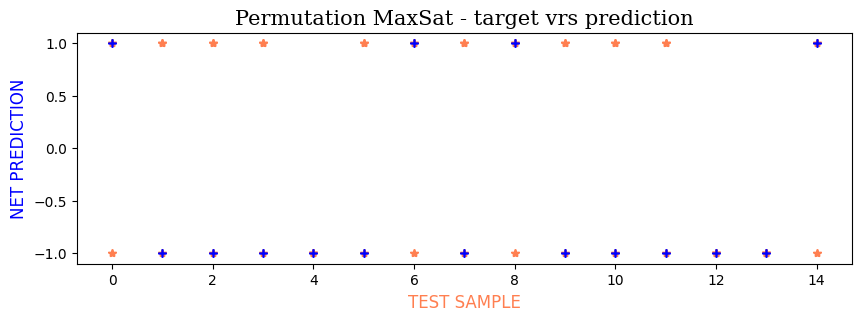

In [109]:
# TARGET vrs PREDICTION PLOT
plt.rcParams["figure.figsize"] = [10, 3]

font1 = {"color":"coral", "size": 12}
font2 = {"color": "blue", "size": 12}
font3 = {"family" : "Serif", "size": 15}

plt.xlabel("TEST SAMPLE", font1)
plt.ylabel("NET PREDICTION", font2)
plt.plot(y_target_test1, "*", color = "coral")
plt.plot(y_pred_test1, "+", color = "blue")
plt.title("Permutation MaxSat - target vrs prediction", font3)
plt.show()

#### NAIVE SEARCH

In [110]:
# TEST SET PREDICTION and ACCURACY CALCULATION - BOTH WITHOUT HIDDEN LAYER AND WITH HIDDEN LAYERS (OR, XOR ...)
                                               # & BOTH FOR ONE SINGLE OUTPUT AND MORE (n = 1 or n > 1)
# some useful prints
print ("TESTING OF MY NET ([data, label]) =====>")
####################################################

##print(X_test)
#print(w1) # best weights (5*3) - row*col
#print(w1[0]) # first col compose by 5 element
#print(w1[1]) # second col compose by 5 element
#print(w1[2]) # third col compose by 5 element

y_target_test2 = [] # contains all the labels for every example in the test
y_pred_test2 = [] # contains all the model predictions for the test set

for i in range(0, len(X_test)): # I scroll all the elements ot the test set (from 0 to [len(X_test)-1])

    # y_target_test1 costruction
    if (n==1): # target composed from one single lable
      y_pred = pred(w2, X_test[i][0]) # model prediction
      y_target_test2.append(X_test[i][1]) # I append for the example i, the single lable presents in position 1

    else: # target composed from more lables
      y_pred = []
      for k in w2: # I scroll all the weights subvector
        y_pred_sub = pred(k, X_test[i][0])  # model prediction of each col in the weights vector (3 or 5)
        y_pred.append(y_pred_sub)

      y_target_test_row = []
      for j in range(1, n+1):  # y_target_test1 costruction
        y_target_test_row.append(X_test[i][j]) # I append for the example i, the the lables form position 1 to j+1

      y_target_test2.append(y_target_test_row)

    y_pred_test2.append(y_pred)

print ("+--------------------------------------+")
print ("METHOD TESTED: Naive Search")

# STANDARD ACCURACY
# print(f"ACCURACY obtained: {accuracy_score(y_target_test2, y_pred_test2)* 100:05.2f} %")

# BALANCED ACCURACY
if (n==1): # one single output
  print(f"BALANCED ACCURACY obtained: {balanced_accuracy_score(y_target_test2, y_pred_test2)* 100:05.2f} %")

else:  # always for the complex net
  y_target_test2_arg = list(np.concatenate(y_target_test2))
  y_pred_test2_arg = list(np.concatenate(y_pred_test2))
  print(f"BALANCED ACCURACY obtained: {balanced_accuracy_score(y_target_test2_arg, y_pred_test2_arg)* 100:05.2f} %")

print ("+--------------------------------------+")
print("Number of examples in the TEST SET:", len(X_test))
print("Number of tested examples:", len(y_pred_test2))
print("OKAY, Net TESTED :-) <<")

TESTING OF MY NET ([data, label]) =====>
+--------------------------------------+
METHOD TESTED: Naive Search
BALANCED ACCURACY obtained: 55.45 %
+--------------------------------------+
Number of examples in the TEST SET: 15
Number of tested examples: 15
OKAY, Net TESTED :-) <<


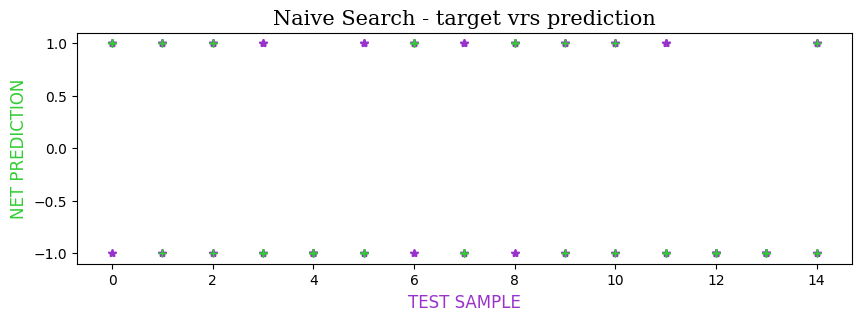

In [111]:
# TARGET vrs PREDICTION PLOT
plt.rcParams["figure.figsize"] = [10, 3]

font1 = {"color":"darkorchid", "size": 12}
font2 = {"color": "limegreen", "size": 12}
font3 = {"family" : "Serif", "size": 15}

plt.xlabel("TEST SAMPLE", font1)
plt.ylabel("NET PREDICTION", font2)
plt.plot(y_target_test2, "*", color = "darkorchid")
plt.plot(y_pred_test2, "+", color = "limegreen")
plt.title("Naive Search - target vrs prediction", font3)
plt.show()

#### CLAUSES MAXSAT

In [112]:
# TEST SET PREDICTION and ACCURACY CALCULATION - BOTH WITHOUT HIDDEN LAYER AND WITH HIDDEN LAYERS (OR, XOR ...)
                                               # & BOTH FOR ONE SINGLE OUTPUT AND MORE (n = 1 or n > 1)
# some useful prints
print ("TESTING OF MY NET ([data, label]) =====>")
####################################################

##print(X_test)
#print(w1) # best weights (5*3) - row*col
#print(w1[0]) # first col compose by 5 element
#print(w1[1]) # second col compose by 5 element
#print(w1[2]) # third col compose by 5 element

y_target_test3 = [] # contains all the labels for every example in the test
y_pred_test3 = [] # contains all the model predictions for the test set

for i in range(0, len(X_test)): # I scroll all the elements ot the test set (from 0 to [len(X_test)-1])

    # y_target_test1 costruction
    if (n==1): # target composed from one single lable
      y_pred = pred(w3, X_test[i][0]) # model prediction
      y_target_test3.append(X_test[i][1]) # I append for the example i, the single lable presents in position 1

    else: # target composed from more lables
      y_pred = []
      for k in w3: # I scroll all the weights subvector
        y_pred_sub = pred(k, X_test[i][0])  # model prediction of each col in the weights vector (3 or 5)
        y_pred.append(y_pred_sub)

      y_target_test_row = []
      for j in range(1, n+1):  # y_target_test1 costruction
        y_target_test_row.append(X_test[i][j]) # I append for the example i, the the lables form position 1 to j+1

      y_target_test3.append(y_target_test_row)

    y_pred_test3.append(y_pred)

print ("+--------------------------------------+")
print ("METHOD TESTED: Clauses MaxSat")

# STANDARD ACCURACY
# print(f"ACCURACY obtained: {accuracy_score(y_target_test3, y_pred_test3)* 100:05.2f} %")

# BALANCED ACCURACY
if (n==1): # one single output
  print(f"BALANCED ACCURACY obtained: {balanced_accuracy_score(y_target_test3, y_pred_test3)* 100:05.2f} %")

else:  # always for the complex net
  y_target_test3_arg = list(np.concatenate(y_target_test3))
  y_pred_test3_arg = list(np.concatenate(y_pred_test3))
  print(f"BALANCED ACCURACY obtained: {balanced_accuracy_score(y_target_test3_arg, y_pred_test3_arg)* 100:05.2f} %")

print ("+--------------------------------------+")
print("Number of examples in the TEST SET:", len(X_test))
print("Number of tested examples:", len(y_pred_test3))
print("OKAY, Net TESTED :-) <<")

TESTING OF MY NET ([data, label]) =====>
+--------------------------------------+
METHOD TESTED: Clauses MaxSat
BALANCED ACCURACY obtained: 56.41 %
+--------------------------------------+
Number of examples in the TEST SET: 15
Number of tested examples: 15
OKAY, Net TESTED :-) <<


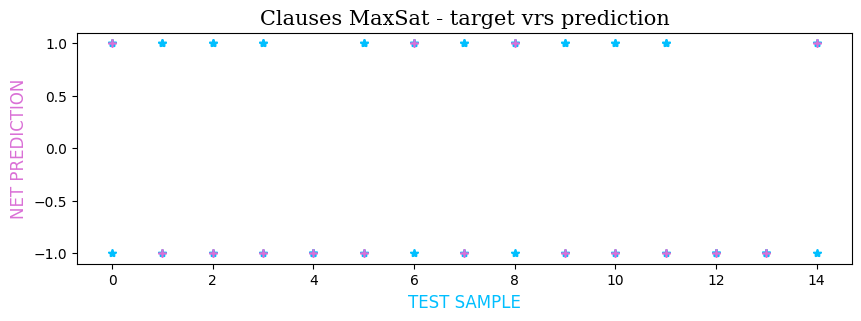

In [113]:
# TARGET vrs PREDICTION PLOT
plt.rcParams["figure.figsize"] = [10, 3]

font1 = {"color":"deepskyblue", "size": 12}
font2 = {"color": "orchid", "size": 12}
font3 = {"family" : "Serif", "size": 15}

plt.xlabel("TEST SAMPLE", font1)
plt.ylabel("NET PREDICTION", font2)
plt.plot(y_target_test3, "*", color = "deepskyblue")
plt.plot(y_pred_test3, "+", color = "orchid")
plt.title("Clauses MaxSat - target vrs prediction", font3)
plt.show()

## SOMETHING MORE ... ⚛

To understand better how each algorithm I developed behaved, during the testing phase, I realized several experiments (more than those included in this notebook), by retraining and testing different *BNNs* architectures and creating different datasets.

In particular, the changes I made concern the:
* number of **examples** in the dataset;
* number of **input neurons** of the net;
* number of **output neurons** of the net;
* number and type of **binary functions** implemented - SINGLE PERCEPTRON or MULTILAYER PERCEPTRON inspiration.

I will discuss all these results in more depth during the oral presentation thanks also to the integration with the demo.

In [114]:
print("THE END :-)")

THE END :-)
